In [64]:
import pandas as pd

In [65]:
stops = pd.read_csv('stop_and_search.csv')

In [66]:
stops = stops.drop(['Unnamed: 0'],axis=1)

In [67]:
stops

,age_range,outcome,object_of_search,latitude,longitude,street_id
0,25-34,A no further action disposal,Controlled drugs,51.508588,-0.074039,1686590
1,25-34,A no further action disposal,Controlled drugs,51.509785,-0.068095,1687860
2,over 34,A no further action disposal,Article for use in theft,51.513647,-0.074330,1490955
3,over 34,Arrest,Article for use in theft,51.513647,-0.074330,1490955
4,25-34,Arrest,Article for use in theft,51.513647,-0.074330,1490955
...,...,...,...,...,...,...
417,18-24,Arrest,Stolen goods,51.525424,-0.023867,1693544
418,18-24,A no further action disposal,Offensive weapons,51.515816,-0.056482,1689527
419,over 34,A no further action disposal,Controlled drugs,51.525582,-0.059209,1689219
420,25-34,Arrest,Offensive weapons,51.513763,-0.039015,1691842


In [68]:
pd.unique(stops['outcome'])

array(['A no further action disposal', 'Arrest',
       'Khat or Cannabis warning', 'Summons / charged by post',
       'Community resolution', 'Penalty Notice for Disorder',
       'Caution (simple or conditional)'], dtype=object)

In [69]:
pd.unique(stops['object_of_search'])

array(['Controlled drugs', 'Article for use in theft', 'Stolen goods',
       'Offensive weapons', 'Evidence of offences under the Act'],
      dtype=object)

We don't need location data at this stage, so we remove it.

In [70]:
stops = stops.drop(['latitude','longitude','street_id'],axis=1)

In [71]:
grouped = stops.groupby(['age_range', 'outcome', 'object_of_search']).size()

In [72]:
grouped = grouped.reset_index(name='count')

In [73]:
# Note that this view was created for a different purpose in mind. For
# final grouped table, see pivot
grouped

,age_range,outcome,object_of_search,count
0,10-17,A no further action disposal,Article for use in theft,1
1,10-17,A no further action disposal,Evidence of offences under the Act,1
2,10-17,A no further action disposal,Offensive weapons,2
3,10-17,A no further action disposal,Stolen goods,7
4,10-17,Arrest,Article for use in theft,1
5,10-17,Arrest,Controlled drugs,2
6,10-17,Arrest,Offensive weapons,3
7,10-17,Arrest,Stolen goods,4
8,10-17,Community resolution,Controlled drugs,1
9,10-17,Penalty Notice for Disorder,Stolen goods,1


In [74]:
pivot = pd.pivot_table(
    grouped,
    index='age_range',
    columns='object_of_search',
    values='count',
    aggfunc='sum',
    fill_value=0
)

In [75]:
pivot=pivot.drop(['Evidence of offences under the Act'], axis=1)

In [76]:
pivot

object_of_search,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods
age_range,,,,
10-17,2,4,5,12
18-24,1,88,11,12
25-34,2,93,14,10
over 34,2,128,8,19


In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

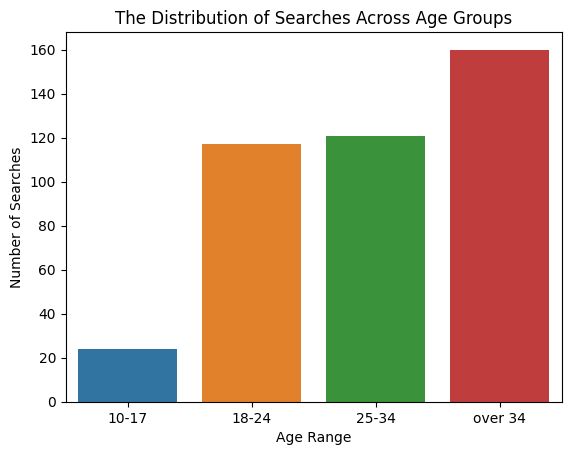

In [78]:

ax = sns.barplot(
    grouped.groupby('age_range').sum().drop(['outcome','object_of_search'], axis=1).T
)
ax.set_ylabel('Number of Searches')
ax.set_xlabel('Age Range')
ax.set_title('The Distribution of Searches Across Age Groups');

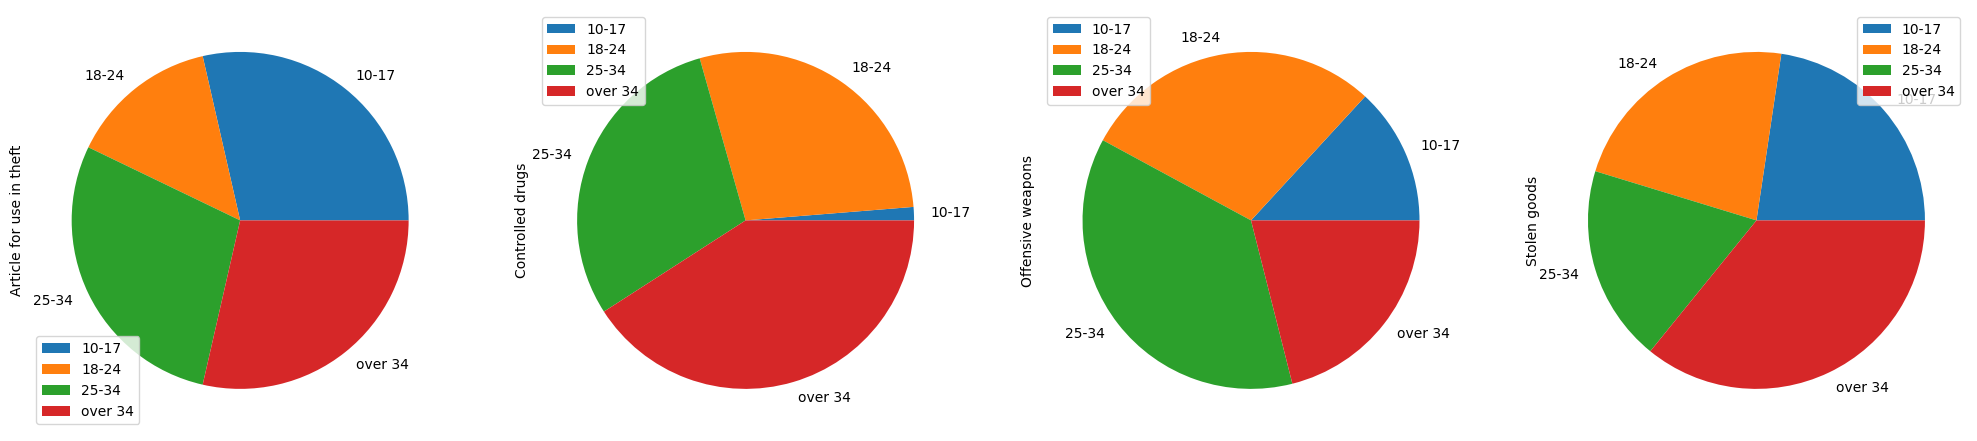

In [79]:
pivot.plot(kind='pie', subplots=True, figsize=(25,30));

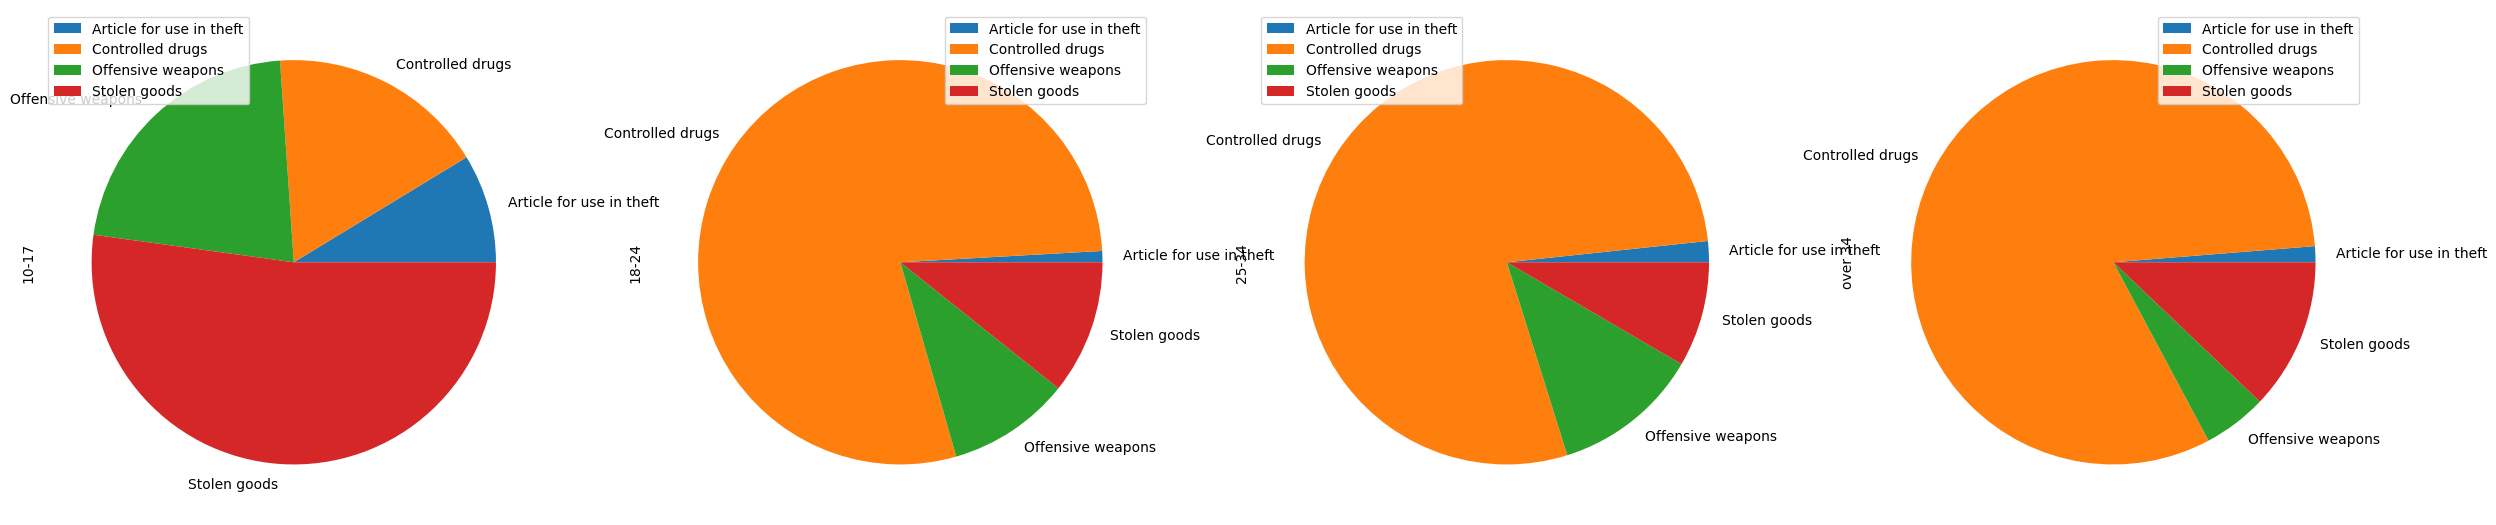

In [80]:
pivot.T.plot(kind='pie', subplots=True, figsize=(30,45));

In [81]:
pivot['total'] = pivot.sum(axis=1)

In [82]:
pivot

object_of_search,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods,total
age_range,,,,,
10-17,2,4,5,12,23
18-24,1,88,11,12,112
25-34,2,93,14,10,119
over 34,2,128,8,19,157


In [83]:
pivot.columns.name = None

In [84]:
percent_pivot = pivot.drop(['total'], axis=1).div(pivot['total'], axis=0) * 100
percent_pivot

,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods
age_range,,,,
10-17,8.695652,17.391304,21.739130,52.173913
18-24,0.892857,78.571429,9.821429,10.714286
25-34,1.680672,78.151261,11.764706,8.403361
over 34,1.273885,81.528662,5.095541,12.101911


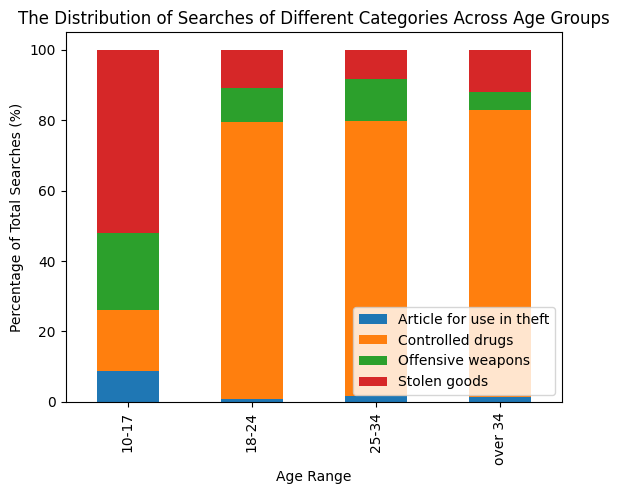

In [85]:
ax = percent_pivot.plot(kind='bar', stacked=True)
ax.set_ylabel('Percentage of Total Searches (%)')
ax.set_xlabel('Age Range')
ax.set_title('The Distribution of Searches of Different Categories Across Age Groups');

pie. barplot stacked,

In [86]:
pivot.pop('total')

age_range
10-17       23
18-24      112
25-34      119
over 34    157
Name: total, dtype: int64

In [87]:
pivot

,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods
age_range,,,,
10-17,2,4,5,12
18-24,1,88,11,12
25-34,2,93,14,10
over 34,2,128,8,19


In [88]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [89]:
from sklearn.metrics import silhouette_samples

In [90]:
pivot

,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods
age_range,,,,
10-17,2,4,5,12
18-24,1,88,11,12
25-34,2,93,14,10
over 34,2,128,8,19


In [91]:
X = pivot.reset_index().drop(columns=['age_range'])
X_scaled = StandardScaler().fit_transform(X)
cols = pivot.columns.to_list()

for i in range(2,4):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    clusters = kmeans.fit(X_scaled)
    display(pd.DataFrame(kmeans.cluster_centers_, columns=X.columns))
    pivot[f'cluster_{i}'] = clusters.labels_
    pivot[f'silhouette_{i}'] = silhouette_samples(
    pivot[cols], pivot[f'cluster_{i}']
    )
    

,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods
0,-0.19245,0.543309,0.447214,0.121879
1,0.57735,-1.629926,-1.341641,-0.365636


,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods
0,-0.57735,0.268910,0.894427,-0.658145
1,0.57735,1.092105,-0.447214,1.681927
2,0.57735,-1.629926,-1.341641,-0.365636


In [92]:
pd.DataFrame(X_scaled)

,0,1,2,3
0,0.577350,-1.629926,-1.341641,-0.365636
1,-1.732051,0.214031,0.447214,-0.365636
2,0.577350,0.323790,1.341641,-0.950654
3,0.577350,1.092105,-0.447214,1.681927


In [93]:
pivot

,Article for use in theft,Controlled drugs,Offensive weapons,Stolen goods,cluster_2,silhouette_2,cluster_3,silhouette_3
age_range,,,,,,,,
10-17,2,4,5,12,1,0.000000,2,0.000000
18-24,1,88,11,12,0,0.721112,0,0.846676
25-34,2,93,14,10,0,0.760393,0,0.829527
over 34,2,128,8,19,0,0.688635,1,0.000000


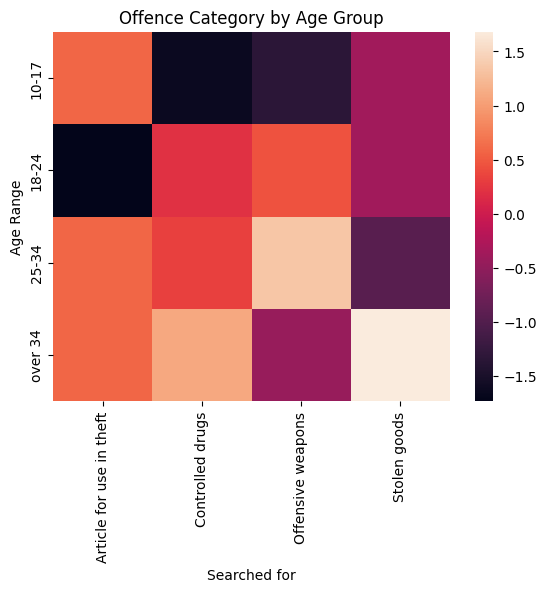

In [94]:
x_scaled_df = pd.DataFrame(X_scaled, index=[pivot.index], columns=[pivot.columns[:-4]])
ax = sns.heatmap(x_scaled_df)
ax.set_ylabel('Age Range')
ax.set_xlabel('Searched for')
plt.title('Offence Category by Age Group')
plt.show()